# Contrast Saturation Local (CSL)

In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

In [2]:
import sys

sys.path.append(str(Path('../..').parent))

from utils import plot_stim

In [3]:
import yaml

with open('../../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

In [4]:
pixel_size_um = 10

crop_setup1_h = config["qdspy"]["crop"]["setup1"]["h"]
crop_setup1_v = config["qdspy"]["crop"]["setup1"]["v"]

crop_setup3_h = config["qdspy"]["crop"]["setup3"]["h"]
crop_setup3_v = config["qdspy"]["crop"]["setup3"]["v"]

In [5]:
out_dir = Path(config["output_dir"])
os.makedirs(out_dir, exist_ok=True)

In [6]:
qdspy_export_dir = Path(config["qdspy"]["export_dir"])
os.listdir(qdspy_export_dir)

['Contrast_saturation_60Hz_10um_pixels.mp4',
 'Contrast_saturation_60Hz_10um_pixels.npz',
 'Contrast_saturation_60Hz_10um_pixels_mark.npz']

In [7]:
csl_file = 'Contrast_saturation_60Hz_10um_pixels.npz'
csl_mark_file = 'Contrast_saturation_60Hz_10um_pixels_mark.npz'

In [8]:
csl = np.load(os.path.join(qdspy_export_dir, csl_file))['data']
csl = np.round(np.mean(csl, axis=-1)).astype(int)
csl.shape

(3720, 120, 120)

In [9]:
csl_mark = np.load(os.path.join(qdspy_export_dir, csl_mark_file))['data']
csl_mark = np.append(csl_mark[:-1] & (~csl_mark[1:]), False)
csl_mark

array([False, False, False, ..., False, False, False], shape=(3720,))

In [10]:
time_csl = np.arange(csl.shape[0]) * 1./60.

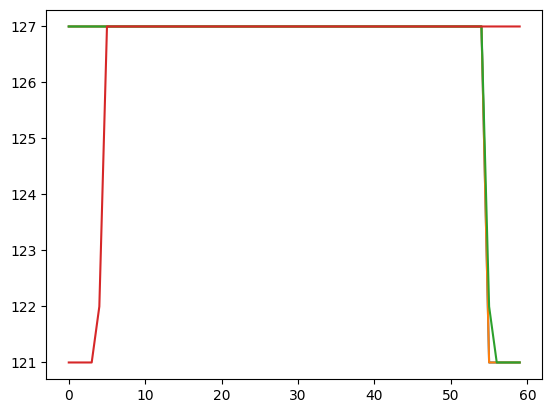

In [11]:
# Checking that the stimulus is centered correctly

x_center = csl.shape[1]//2
y_center = csl.shape[2]//2
t_s = 10

plt.plot(csl[int(60*t_s), y_center, x_center:][::-1])
plt.plot(csl[int(60*t_s), y_center, :x_center])
plt.plot(csl[int(60*t_s), :y_center, x_center])
plt.plot(csl[int(60*t_s), y_center:, x_center])

plt.show()

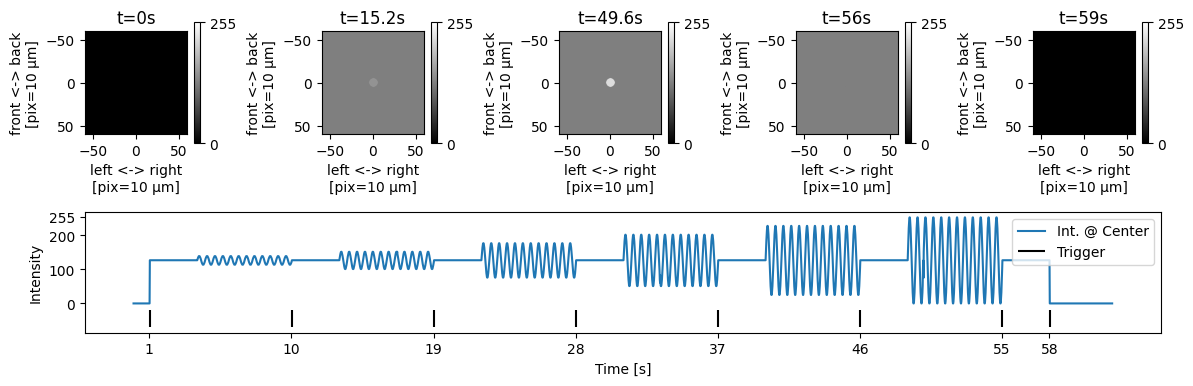

In [12]:
t_s_plot = (0, 15.2, 49.6, 56, 59)

plot_stim(csl, csl_mark, time_csl, t_s_plot=t_s_plot);

In [13]:
# No rotation / flips necessary as stimulus is point-symmetric. Just cropping to the same size as the other stimuli.
csl_setup1 = csl[:, crop_setup1_v:-crop_setup1_v, crop_setup1_h:-crop_setup1_h]
csl_setup3 = csl[:, crop_setup3_v:-crop_setup3_v, crop_setup3_h:-crop_setup3_h]

In [14]:
stim_dict = {
    ('csl', '1'): csl_setup1,
    #('csl', '3'): csl_setup3,  # Same on both setups
}

Plotting csl


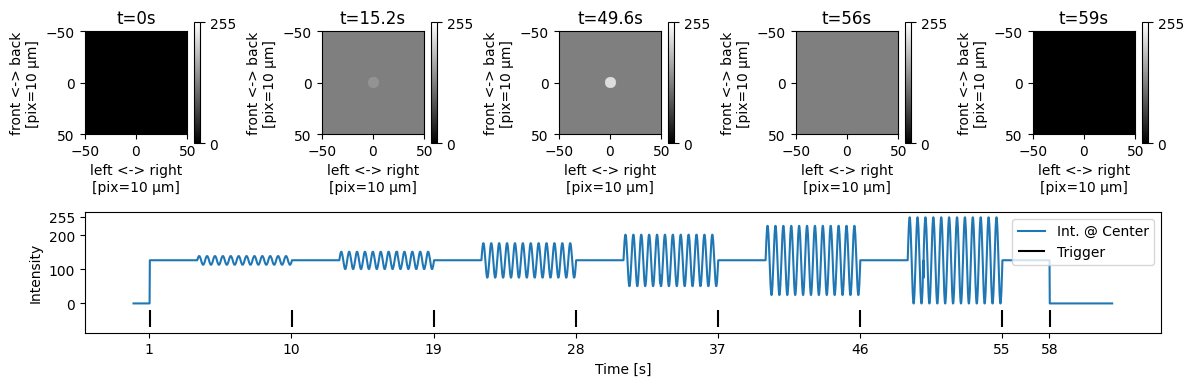

In [15]:
for (name, setup), stim in stim_dict.items():
    print(f'Plotting {name}')
    
    fig, axs = plot_stim(stim, csl_mark, time_csl, t_s_plot=t_s_plot)
    plt.savefig(os.path.join(out_dir, f'{name}.pdf'), bbox_inches='tight')
    plt.show()

In [16]:
target_freq = 60
assert np.isclose(target_freq, np.round(1 / np.mean(np.diff(time_csl))))

assert np.all(csl_setup1.astype(np.uint8) == csl_setup1)

np.savez_compressed(
    os.path.join(out_dir, 'csl_movie_and_trigger'),  # This stimulus is the same on all setups
    stimulus=csl_setup1.astype(np.uint8),
    time=time_csl.astype(np.float32),
    trigger=csl_mark,
    framerate=target_freq,
    pixel_size_um=pixel_size_um,
)